<a href="https://colab.research.google.com/github/oaalikouche12-bot/reto-telefonica/blob/main/Reto_Telefonica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Detección de voz falsa mediante IA

## Introducción

En este proyecto se aborda el problema de la detección de voz falsa mediante inteligencia artificial. El objetivo principal es construir un sistema capaz de distinguir entre muestras de voz auténticas y muestras manipuladas, sintetizadas o generadas artificialmente.

Este trabajo sigue la propuesta del reto, en la que se plantea trabajar con verificación de hablantes utilizando muestras de voz. Además, la motivación del problema es muy actual, ya que la clonación de voz y los deepfakes de audio representan una amenaza creciente en contextos de fraude, suplantación de identidad y manipulación.

La detección de voz falsa a gran escala presenta desafíos importantes. Entre las razones por las que el uso de inteligencia artificial es fundamental destacan:
1. La complejidad de las técnicas de suplantación.
2. La escalabilidad y la variabilidad de los datos.
3. La adaptabilidad a nuevas amenazas.
4. La capacidad de extraer características avanzadas.

## Objetivo

El objetivo de este notebook es construir un primer pipeline de trabajo completo:
1. Cargar los datasets desde Google Drive.
2. Descomprimir los archivos.
3. Explorar la estructura de los datos.
4. Localizar los archivos de audio.
5. Transformar los audios en variables numéricas.
6. Entrenar un modelo baseline de clasificación.
7. Evaluar su rendimiento.

## Datasets utilizados

Se trabajará con los datasets disponibles en el reto:
- ASVspoof 2019
- Latin-American voice anti-spoofing dataset
- Posibles conjuntos adicionales o personalizados si hiciera falta

In [ ]:
# Montar Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Tenéis que cambiar esta ruta de ejemplo y poner la vuestra
%cd "/content/drive/MyDrive/Colab Notebooks/Master/Tercer Trimestre/Reto de la inteligencia artifical"

/content/drive/MyDrive/Colab Notebooks/Master/Tercer Trimestre/Reto de la inteligencia artifical


## Librerías necesarias

Para este proyecto utilizaremos:
- `librosa` para cargar y procesar audio
- `pandas` y `numpy` para trabajar con los datos
- `matplotlib` y `seaborn` para visualizar
- `scikit-learn` para entrenar y evaluar modelos

Como uno de los datasets está comprimido en formato `.rar`, también instalaremos herramientas para descomprimirlo en Colab.

In [ ]:
!apt-get -qq install unrar
!pip install -q librosa soundfile rarfile

## Importación de librerías

A continuación se importan todas las librerías necesarias para el proyecto.

In [ ]:
import os
import zipfile
import subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import librosa
import soundfile as sf

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Definición de la carpeta de trabajo

Como ya se ha cambiado correctamente a la carpeta del proyecto mediante `%cd`, se utilizará la ruta actual como carpeta base. A partir de ella se definirán los archivos comprimidos y la carpeta donde se extraerán los datos.

In [ ]:
BASE_DIR = Path.cwd()

RAR_FILE = BASE_DIR / "Latin_America_Spanish_anti_spoofing_dataset.rar"
ZIP_FILE_1 = BASE_DIR / "DS_10283_3336.zip"
ZIP_FILE_2 = BASE_DIR / "7370805.zip"

WORK_DIR = Path("/content/voice_project")
EXTRACT_DIR = WORK_DIR / "data"

WORK_DIR.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

print("BASE_DIR:", BASE_DIR)
print("RAR exists:", RAR_FILE.exists(), RAR_FILE)
print("ZIP 1 exists:", ZIP_FILE_1.exists(), ZIP_FILE_1)
print("ZIP 2 exists:", ZIP_FILE_2.exists(), ZIP_FILE_2)
print("\nContenido de la carpeta base:")
print(os.listdir())

BASE_DIR: /content/drive/MyDrive/Colab Notebooks/Master/Tercer Trimestre/Reto de la inteligencia artifical
RAR exists: True /content/drive/MyDrive/Colab Notebooks/Master/Tercer Trimestre/Reto de la inteligencia artifical/Latin_America_Spanish_anti_spoofing_dataset.rar
ZIP 1 exists: True /content/drive/MyDrive/Colab Notebooks/Master/Tercer Trimestre/Reto de la inteligencia artifical/DS_10283_3336.zip
ZIP 2 exists: True /content/drive/MyDrive/Colab Notebooks/Master/Tercer Trimestre/Reto de la inteligencia artifical/7370805.zip

Contenido de la carpeta base:
['Reto Telefonica', '7370805.zip', 'Latin_America_Spanish_anti_spoofing_dataset.rar', 'DS_10283_3336.zip']


## Funciones de descompresión

Se definen funciones auxiliares para extraer archivos comprimidos en formato `.zip` y `.rar`. Dado que los datasets son grandes, se recomienda empezar con un único archivo para comprobar que el flujo funciona correctamente.

In [ ]:
def extract_zip(zip_path, out_dir):
    if zip_path.exists():
        out_dir.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(zip_path, 'r') as z:
            z.extractall(out_dir)
        print(f"Extraído ZIP: {zip_path.name} -> {out_dir}")
    else:
        print(f"No encontrado: {zip_path}")

def extract_rar(rar_path, out_dir):
    if rar_path.exists():
        out_dir.mkdir(parents=True, exist_ok=True)
        cmd = ["unrar", "x", "-o+", str(rar_path), str(out_dir)]
        subprocess.run(cmd, check=False)
        print(f"Extraído RAR: {rar_path.name} -> {out_dir}")
    else:
        print(f"No encontrado: {rar_path}")

## Primera extracción de prueba

Se comenzará extrayendo únicamente el archivo `DS_10283_3336.zip`, con el objetivo de validar que el proceso funciona correctamente antes de descomprimir el resto.

In [ ]:
extract_zip(ZIP_FILE_1, EXTRACT_DIR / "dataset_zip_1")

Extraído ZIP: DS_10283_3336.zip -> /content/voice_project/data/dataset_zip_1


## Exploración del contenido extraído

Una vez descomprimido el segundo archivo, se inspeccionará su estructura interna para localizar audios, carpetas relevantes y posibles archivos auxiliares.

In [ ]:
def show_tree(root, max_items=120):
    root = Path(root)
    items = list(root.rglob("*"))
    print(f"Mostrando hasta {max_items} elementos de {root}:")
    for p in items[:max_items]:
        print(p)

In [ ]:
show_tree(EXTRACT_DIR / "dataset_zip_1", max_items=150)

Mostrando hasta 150 elementos de /content/voice_project/data/dataset_zip_1:
/content/voice_project/data/dataset_zip_1/README.txt
/content/voice_project/data/dataset_zip_1/asvspoof2019_Interspeech2019_submission.pdf
/content/voice_project/data/dataset_zip_1/LA.zip
/content/voice_project/data/dataset_zip_1/LICENSE_text.txt
/content/voice_project/data/dataset_zip_1/asvspoof2019_evaluation_plan.pdf
/content/voice_project/data/dataset_zip_1/PA.zip


## Búsqueda de archivos de audio

Una vez inspeccionada la estructura del dataset, se buscarán todos los archivos de audio disponibles para construir una tabla inicial de metadatos.

In [ ]:
AUDIO_EXTS = {".wav", ".flac", ".mp3", ".m4a", ".ogg"}

audio_files = []
for p in (EXTRACT_DIR / "dataset_zip_1").rglob("*"):
    if p.is_file() and p.suffix.lower() in AUDIO_EXTS:
        audio_files.append(p)

print("Número total de audios encontrados:", len(audio_files))
audio_files[:20]

Número total de audios encontrados: 0


[]

In [ ]:
from collections import Counter
from pathlib import Path

ext_counter = Counter()

for p in (EXTRACT_DIR / "dataset_zip_1").rglob("*"):
    if p.is_file():
        ext_counter[p.suffix.lower()] += 1

print("Extensiones encontradas:")
for ext, count in ext_counter.most_common(50):
    print(f"{ext if ext else '[sin extensión]'}: {count}")

Extensiones encontradas:
.txt: 2
.pdf: 2
.zip: 2


In [ ]:
meta_files = []
for p in (EXTRACT_DIR / "dataset_zip_1").rglob("*"):
    if p.is_file() and p.suffix.lower() in {".txt", ".csv", ".tsv", ".json", ".xml"}:
        meta_files.append(p)

print("Número de archivos auxiliares encontrados:", len(meta_files))
for p in meta_files[:100]:
    print(p)

Número de archivos auxiliares encontrados: 2
/content/voice_project/data/dataset_zip_1/README.txt
/content/voice_project/data/dataset_zip_1/LICENSE_text.txt


In [ ]:
inner_archives = []
for p in (EXTRACT_DIR / "dataset_zip_1").rglob("*"):
    if p.is_file() and p.suffix.lower() in {".zip", ".rar", ".7z", ".tar", ".gz"}:
        inner_archives.append(p)

print("Archivos comprimidos internos encontrados:", len(inner_archives))
for p in inner_archives[:50]:
    print(p)

Archivos comprimidos internos encontrados: 2
/content/voice_project/data/dataset_zip_1/LA.zip
/content/voice_project/data/dataset_zip_1/PA.zip


In [ ]:
show_tree(EXTRACT_DIR / "dataset_zip_1", max_items=300)

Mostrando hasta 300 elementos de /content/voice_project/data/dataset_zip_1:
/content/voice_project/data/dataset_zip_1/README.txt
/content/voice_project/data/dataset_zip_1/asvspoof2019_Interspeech2019_submission.pdf
/content/voice_project/data/dataset_zip_1/LA.zip
/content/voice_project/data/dataset_zip_1/LICENSE_text.txt
/content/voice_project/data/dataset_zip_1/asvspoof2019_evaluation_plan.pdf
/content/voice_project/data/dataset_zip_1/PA.zip


In [ ]:
AUDIO_EXTS_WIDE = {
    ".wav", ".flac", ".mp3", ".m4a", ".ogg",
    ".aac", ".opus", ".wma", ".sph", ".au", ".aiff"
}

audio_files = []
for p in (EXTRACT_DIR / "dataset_zip_1").rglob("*"):
    if p.is_file() and p.suffix.lower() in AUDIO_EXTS_WIDE:
        audio_files.append(p)

print("Número total de audios encontrados:", len(audio_files))
audio_files[:30]

Número total de audios encontrados: 0


[]

## Extracción de archivos internos

El archivo `DS_10283_3336.zip` no contiene los audios directamente, sino que incluye dos archivos comprimidos internos, `LA1.zip` y `LA2.zip`. Por tanto, el siguiente paso es extraer ambos archivos para acceder a las muestras de audio.

In [ ]:
INNER_ZIP_1 = EXTRACT_DIR / "dataset_zip_1" / "LA1.zip"
INNER_ZIP_2 = EXTRACT_DIR / "dataset_zip_1" / "LA2.zip"

print("INNER_ZIP_1 exists:", INNER_ZIP_1.exists(), INNER_ZIP_1)
print("INNER_ZIP_2 exists:", INNER_ZIP_2.exists(), INNER_ZIP_2)

INNER_ZIP_1 exists: False /content/voice_project/data/dataset_zip_1/LA1.zip
INNER_ZIP_2 exists: False /content/voice_project/data/dataset_zip_1/LA2.zip


In [ ]:
extract_zip(INNER_ZIP_1, EXTRACT_DIR / "LA1")
extract_zip(INNER_ZIP_2, EXTRACT_DIR / "LA2")

No encontrado: /content/voice_project/data/dataset_zip_1/LA1.zip
No encontrado: /content/voice_project/data/dataset_zip_1/LA2.zip


In [ ]:
inner_zips = list((EXTRACT_DIR / "dataset_zip_1").rglob("LA*.zip"))

print("ZIPs internos encontrados:")
for z in inner_zips:
    print(z)

ZIPs internos encontrados:
/content/voice_project/data/dataset_zip_1/LA.zip


In [ ]:
INNER_ZIP_2 = inner_zips[0]

print("INNER_ZIP_2:", INNER_ZIP_2)
print("Existe LA2:", INNER_ZIP_2.exists())

INNER_ZIP_2: /content/voice_project/data/dataset_zip_1/LA.zip
Existe LA2: True


In [ ]:
extract_zip(INNER_ZIP_2, EXTRACT_DIR / "LA2")

Extraído ZIP: LA.zip -> /content/voice_project/data/LA2


In [ ]:
AUDIO_EXTS_WIDE = {
    ".wav", ".flac", ".mp3", ".m4a", ".ogg",
    ".aac", ".opus", ".wma", ".sph", ".au", ".aiff"
}

audio_files = []
for p in (EXTRACT_DIR / "LA2").rglob("*"):
    if p.is_file() and p.suffix.lower() in AUDIO_EXTS_WIDE:
        audio_files.append(p)

print("Número total de audios encontrados:", len(audio_files))
audio_files[:30]

Número total de audios encontrados: 122299


[PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_2679566.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_6379912.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_8998030.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_7144134.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_8995196.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_1825261.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_4554352.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_4310384.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_2062147.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_3958124.flac'),
 PosixPath('/content/voice_project/data/LA2/LA/ASV

## Confirmación del dataset de audio

Tras extraer el archivo interno válido, se han localizado correctamente los audios del dataset. En total se han encontrado miles de muestras en formato `.flac`, organizadas dentro de la estructura de ASVspoof 2019 para Latinoamérica.

Dado que los nombres de archivo no contienen directamente la etiqueta de clase, el siguiente paso será localizar los archivos de protocolo o metadatos oficiales para asignar correctamente si cada audio es bona fide o spoof.

In [ ]:
print("Número total de audios encontrados:", len(audio_files))

print("\nPrimeros 10 audios:")
for p in audio_files[:10]:
    print(p)

Número total de audios encontrados: 122299

Primeros 10 audios:
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_2679566.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_6379912.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_8998030.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_7144134.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_8995196.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_1825261.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_4554352.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_4310384.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_2062147.flac
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/flac/LA_T_3958124.flac


## Búsqueda de archivos de protocolo y metadatos

Los datasets de ASVspoof suelen incluir archivos auxiliares con la información necesaria para etiquetar cada muestra. Por ello, se buscarán archivos de texto, CSV, TSV o similares dentro de la carpeta extraída.

In [ ]:
meta_files = []
for p in (EXTRACT_DIR / "LA2").rglob("*"):
    if p.is_file() and p.suffix.lower() in {".txt", ".csv", ".tsv", ".json", ".xml", ".trl"}:
        meta_files.append(p)

print("Número de archivos auxiliares encontrados:", len(meta_files))
for p in meta_files[:100]:
    print(p)

Número de archivos auxiliares encontrados: 19
/content/voice_project/data/LA2/LA/README.LA.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_train/LICENSE.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_dev/LICENSE.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_eval/LICENSE.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.male.trl.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.gi.trl.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.eval.female.trn.txt
/content/voice_project/data/LA2/LA/ASVspoof2019_LA_asv_protocols/ASVspoof2019.LA.asv.dev.female.trl.txt
/c

## Identificación del protocolo de etiquetado

Dentro del dataset se han localizado varios archivos de protocolo. Para este proyecto, el más relevante es el conjunto de protocolos `cm` (*countermeasures*), ya que está orientado a la detección de audio genuino frente a audio falsificado o manipulado.

En particular, se utilizarán inicialmente los protocolos de entrenamiento y desarrollo:
- `ASVspoof2019.LA.cm.train.trn.txt`
- `ASVspoof2019.LA.cm.dev.trl.txt`

Estos archivos contienen la información necesaria para asociar cada audio con su etiqueta correspondiente.

In [ ]:
cm_train_protocol = EXTRACT_DIR / "LA2" / "LA" / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.train.trn.txt"
cm_dev_protocol = EXTRACT_DIR / "LA2" / "LA" / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.dev.trl.txt"
cm_eval_protocol = EXTRACT_DIR / "LA2" / "LA" / "ASVspoof2019_LA_cm_protocols" / "ASVspoof2019.LA.cm.eval.trl.txt"

print("TRAIN:", cm_train_protocol.exists(), cm_train_protocol)
print("DEV:", cm_dev_protocol.exists(), cm_dev_protocol)
print("EVAL:", cm_eval_protocol.exists(), cm_eval_protocol)

TRAIN: True /content/voice_project/data/LA2/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.train.trn.txt
DEV: True /content/voice_project/data/LA2/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.dev.trl.txt
EVAL: True /content/voice_project/data/LA2/LA/ASVspoof2019_LA_cm_protocols/ASVspoof2019.LA.cm.eval.trl.txt


## Exploración del formato del protocolo

Antes de unir las etiquetas con los audios, se inspeccionará el contenido del protocolo para entender su estructura y determinar qué columnas contienen el identificador del archivo y la etiqueta de clase.

In [ ]:
for protocol_path in [cm_train_protocol, cm_dev_protocol, cm_eval_protocol]:
    print("=" * 100)
    print("Archivo:", protocol_path.name)
    with open(protocol_path, "r", encoding="utf-8", errors="ignore") as f:
        for _ in range(10):
            line = f.readline()
            if not line:
                break
            print(line.strip())

Archivo: ASVspoof2019.LA.cm.train.trn.txt
LA_0079 LA_T_1138215 - - bonafide
LA_0079 LA_T_1271820 - - bonafide
LA_0079 LA_T_1272637 - - bonafide
LA_0079 LA_T_1276960 - - bonafide
LA_0079 LA_T_1341447 - - bonafide
LA_0079 LA_T_1363611 - - bonafide
LA_0079 LA_T_1596451 - - bonafide
LA_0079 LA_T_1608170 - - bonafide
LA_0079 LA_T_1684951 - - bonafide
LA_0079 LA_T_1699801 - - bonafide
Archivo: ASVspoof2019.LA.cm.dev.trl.txt
LA_0069 LA_D_1047731 - - bonafide
LA_0069 LA_D_1105538 - - bonafide
LA_0069 LA_D_1125976 - - bonafide
LA_0069 LA_D_1293230 - - bonafide
LA_0069 LA_D_1340209 - - bonafide
LA_0069 LA_D_1376638 - - bonafide
LA_0069 LA_D_1377420 - - bonafide
LA_0069 LA_D_1403371 - - bonafide
LA_0069 LA_D_1590530 - - bonafide
LA_0069 LA_D_1595036 - - bonafide
Archivo: ASVspoof2019.LA.cm.eval.trl.txt
LA_0039 LA_E_2834763 - A11 spoof
LA_0014 LA_E_8877452 - A14 spoof
LA_0040 LA_E_6828287 - A16 spoof
LA_0022 LA_E_6977360 - A09 spoof
LA_0031 LA_E_5932896 - A13 spoof
LA_0030 LA_E_5849185 - - bonafid

## Carga correcta de los protocolos

Tras inspeccionar el contenido de los archivos de protocolo, se observa que cada línea contiene cuatro campos:
1. identificador del hablante o sesión
2. identificador del archivo
3. tipo de ataque o símbolo `-`
4. etiqueta final (`bonafide` o `spoof`)

Por tanto, los protocolos se cargarán con cuatro columnas.

In [ ]:
train_protocol = pd.read_csv(cm_train_protocol, sep=r"\s+", header=None)
dev_protocol = pd.read_csv(cm_dev_protocol, sep=r"\s+", header=None)
eval_protocol = pd.read_csv(cm_eval_protocol, sep=r"\s+", header=None)

print("train shape:", train_protocol.shape)
print("dev shape:", dev_protocol.shape)
print("eval shape:", eval_protocol.shape)
display(eval_protocol.head())

train shape: (25380, 5)
dev shape: (24844, 5)
eval shape: (71237, 5)


,0,1,2,3,4
0,LA_0039,LA_E_2834763,-,A11,spoof
1,LA_0014,LA_E_8877452,-,A14,spoof
2,LA_0040,LA_E_6828287,-,A16,spoof
3,LA_0022,LA_E_6977360,-,A09,spoof
4,LA_0031,LA_E_5932896,-,A13,spoof


In [ ]:
display(train_protocol.head())
display(dev_protocol.head())
display(eval_protocol.head())

,0,1,2,3,4
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide


,0,1,2,3,4
0,LA_0069,LA_D_1047731,-,-,bonafide
1,LA_0069,LA_D_1105538,-,-,bonafide
2,LA_0069,LA_D_1125976,-,-,bonafide
3,LA_0069,LA_D_1293230,-,-,bonafide
4,LA_0069,LA_D_1340209,-,-,bonafide


,0,1,2,3,4
0,LA_0039,LA_E_2834763,-,A11,spoof
1,LA_0014,LA_E_8877452,-,A14,spoof
2,LA_0040,LA_E_6828287,-,A16,spoof
3,LA_0022,LA_E_6977360,-,A09,spoof
4,LA_0031,LA_E_5932896,-,A13,spoof


In [ ]:
train_protocol.columns = ["speaker_id", "file_id", "unused_1", "attack_id", "label"]
dev_protocol.columns = ["speaker_id", "file_id", "unused_1", "attack_id", "label"]
eval_protocol.columns = ["speaker_id", "file_id", "unused_1", "attack_id", "label"]

display(train_protocol.head())
display(dev_protocol.head())
display(eval_protocol.head())

,speaker_id,file_id,unused_1,attack_id,label
0,LA_0079,LA_T_1138215,-,-,bonafide
1,LA_0079,LA_T_1271820,-,-,bonafide
2,LA_0079,LA_T_1272637,-,-,bonafide
3,LA_0079,LA_T_1276960,-,-,bonafide
4,LA_0079,LA_T_1341447,-,-,bonafide


,speaker_id,file_id,unused_1,attack_id,label
0,LA_0069,LA_D_1047731,-,-,bonafide
1,LA_0069,LA_D_1105538,-,-,bonafide
2,LA_0069,LA_D_1125976,-,-,bonafide
3,LA_0069,LA_D_1293230,-,-,bonafide
4,LA_0069,LA_D_1340209,-,-,bonafide


,speaker_id,file_id,unused_1,attack_id,label
0,LA_0039,LA_E_2834763,-,A11,spoof
1,LA_0014,LA_E_8877452,-,A14,spoof
2,LA_0040,LA_E_6828287,-,A16,spoof
3,LA_0022,LA_E_6977360,-,A09,spoof
4,LA_0031,LA_E_5932896,-,A13,spoof


In [ ]:
print("Distribución train:")
print(train_protocol["label"].value_counts())

print("\nDistribución dev:")
print(dev_protocol["label"].value_counts())

print("\nDistribución eval:")
print(eval_protocol["label"].value_counts())

Distribución train:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64

Distribución dev:
label
spoof       22296
bonafide     2548
Name: count, dtype: int64

Distribución eval:
label
spoof       63882
bonafide     7355
Name: count, dtype: int64


In [ ]:
# Construimos una tabla básica con todos los audios encontrados.
# Para cada archivo guardamos:
# - filepath: ruta completa del audio
# - filename: nombre del archivo con extensión
# - file_id: nombre base sin extensión, que será la clave para unir con el protocolo
# - suffix: extensión del archivo
# - parent_folder: carpeta donde está guardado

rows = []

for p in audio_files:
    rows.append({
        "filepath": str(p),
        "filename": p.name,
        "file_id": p.stem,          # clave que coincide con el protocolo
        "suffix": p.suffix.lower(),
        "parent_folder": p.parent.name
    })

# Convertimos la lista de diccionarios en un DataFrame
df_files = pd.DataFrame(rows)

# Revisamos tamaño y primeras filas
print("Shape de df_files:", df_files.shape)
display(df_files.head())

Shape de df_files: (122299, 5)


,filepath,filename,file_id,suffix,parent_folder
0,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_2679566.flac,LA_T_2679566,.flac,flac
1,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_6379912.flac,LA_T_6379912,.flac,flac
2,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_8998030.flac,LA_T_8998030,.flac,flac
3,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_7144134.flac,LA_T_7144134,.flac,flac
4,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_8995196.flac,LA_T_8995196,.flac,flac


In [ ]:
# Comprobamos si el identificador del archivo es único.
# Esto es importante porque luego haremos el merge con el protocolo usando file_id.

print("Número de file_id únicos:", df_files["file_id"].nunique())
print("Número total de filas:", len(df_files))

# Si ambos números son iguales, significa que no hay duplicados en file_id.

Número de file_id únicos: 122299
Número total de filas: 122299


In [ ]:
# Unimos la tabla de audios con el protocolo de entrenamiento.
# Solo conservamos:
# - file_id: para emparejar
# - label: etiqueta oficial (bonafide o spoof)

df_train = df_files.merge(
    train_protocol[["file_id", "label"]],
    on="file_id",
    how="inner"   # solo nos quedamos con coincidencias reales
)

# Hacemos lo mismo para el protocolo de desarrollo
df_dev = df_files.merge(
    dev_protocol[["file_id", "label"]],
    on="file_id",
    how="inner"
)

# Revisamos el tamaño del resultado
print("Train merged shape:", df_train.shape)
print("Dev merged shape:", df_dev.shape)

# Mostramos algunas filas para verificar que el merge ha salido bien
display(df_train.head())
display(df_dev.head())

Train merged shape: (25380, 6)
Dev merged shape: (24844, 6)


,filepath,filename,file_id,suffix,parent_folder,label
0,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_2679566.flac,LA_T_2679566,.flac,flac,spoof
1,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_6379912.flac,LA_T_6379912,.flac,flac,spoof
2,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_8998030.flac,LA_T_8998030,.flac,flac,spoof
3,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_7144134.flac,LA_T_7144134,.flac,flac,bonafide
4,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_8995196.flac,LA_T_8995196,.flac,flac,spoof


,filepath,filename,file_id,suffix,parent_folder,label
0,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_2996762.flac,LA_D_2996762,.flac,flac,bonafide
1,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_4342949.flac,LA_D_4342949,.flac,flac,spoof
2,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_4350681.flac,LA_D_4350681,.flac,flac,spoof
3,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_6731562.flac,LA_D_6731562,.flac,flac,spoof
4,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_4884849.flac,LA_D_4884849,.flac,flac,spoof


In [ ]:
# Comprobamos la distribución de clases después del merge.
# Esto nos permite verificar que las etiquetas se han unido correctamente.

print("Distribución train merge:")
print(df_train["label"].value_counts())

print("\nDistribución dev merge:")
print(df_dev["label"].value_counts())

Distribución train merge:
label
spoof       22800
bonafide     2580
Name: count, dtype: int64

Distribución dev merge:
label
spoof       22296
bonafide     2548
Name: count, dtype: int64


In [ ]:
# Convertimos las etiquetas textuales a formato numérico.
# bonafide = 0
# spoof = 1

label_map = {
    "bonafide": 0,
    "spoof": 1
}

df_train["label_num"] = df_train["label"].map(label_map)
df_dev["label_num"] = df_dev["label"].map(label_map)

# Revisamos el resultado
display(df_train.head())
display(df_dev.head())

,filepath,filename,file_id,suffix,parent_folder,label,label_num
0,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_2679566.flac,LA_T_2679566,.flac,flac,spoof,1
1,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_6379912.flac,LA_T_6379912,.flac,flac,spoof,1
2,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_8998030.flac,LA_T_8998030,.flac,flac,spoof,1
3,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_7144134.flac,LA_T_7144134,.flac,flac,bonafide,0
4,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_8995196.flac,LA_T_8995196,.flac,flac,spoof,1


,filepath,filename,file_id,suffix,parent_folder,label,label_num
0,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_2996762.flac,LA_D_2996762,.flac,flac,bonafide,0
1,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_4342949.flac,LA_D_4342949,.flac,flac,spoof,1
2,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_4350681.flac,LA_D_4350681,.flac,flac,spoof,1
3,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_6731562.flac,LA_D_6731562,.flac,flac,spoof,1
4,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_4884849.flac,LA_D_4884849,.flac,flac,spoof,1


In [ ]:
# Como el dataset completo es grande, tomamos una muestra reducida.
# Además, hacemos un muestreo equilibrado por clase para no quedarnos
# con demasiados ejemplos de una sola categoría.

MAX_TRAIN = 1000
MAX_DEV = 500

# Muestreo balanceado para train
df_train_sample = df_train.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), MAX_TRAIN // 2), random_state=42)
).reset_index(drop=True)

# Muestreo balanceado para dev
df_dev_sample = df_dev.groupby("label", group_keys=False).apply(
    lambda x: x.sample(min(len(x), MAX_DEV // 2), random_state=42)
).reset_index(drop=True)

# Comprobamos tamaños y balance
print("Train sample shape:", df_train_sample.shape)
print("Dev sample shape:", df_dev_sample.shape)

print("\nDistribución train sample:")
print(df_train_sample["label"].value_counts())

print("\nDistribución dev sample:")
print(df_dev_sample["label"].value_counts())

Train sample shape: (1000, 7)
Dev sample shape: (500, 7)

Distribución train sample:
label
bonafide    500
spoof       500
Name: count, dtype: int64

Distribución dev sample:
label
bonafide    250
spoof       250
Name: count, dtype: int64


/tmp/ipykernel_22992/1887622793.py:9: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_train_sample = df_train.groupby("label", group_keys=False).apply(
/tmp/ipykernel_22992/1887622793.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_dev_sample = df_dev.groupby("label", group_keys=False).apply(


In [ ]:
# Definimos una función para extraer características acústicas de cada audio.
# Estas características convierten el sonido en variables numéricas que
# luego puede usar un modelo clásico de machine learning.

def extract_features(file_path, sr=16000, duration=4.0):
    try:
        # Cargamos el audio en mono, remuestreado a 16 kHz,
        # y limitamos la duración para que el procesamiento sea más manejable.
        y, sr = librosa.load(file_path, sr=sr, mono=True, duration=duration)

        # Si el audio está vacío, devolvemos None
        if len(y) == 0:
            return None

        feats = {}

        # Duración real cargada
        feats["duration_loaded"] = len(y) / sr

        # Estadísticas básicas de amplitud
        feats["mean_amp"] = np.mean(np.abs(y))
        feats["std_amp"] = np.std(y)

        # Zero Crossing Rate:
        # mide cuántas veces cambia de signo la señal
        zcr = librosa.feature.zero_crossing_rate(y=y)
        feats["zcr_mean"] = np.mean(zcr)
        feats["zcr_std"] = np.std(zcr)

        # RMS:
        # mide la energía media de la señal
        rms = librosa.feature.rms(y=y)
        feats["rms_mean"] = np.mean(rms)
        feats["rms_std"] = np.std(rms)

        # Spectral centroid:
        # indica dónde se concentra el "centro de masa" del espectro
        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)
        feats["centroid_mean"] = np.mean(centroid)
        feats["centroid_std"] = np.std(centroid)

        # Spectral bandwidth:
        # mide la dispersión del espectro
        bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=sr)
        feats["bandwidth_mean"] = np.mean(bandwidth)
        feats["bandwidth_std"] = np.std(bandwidth)

        # Spectral rolloff:
        # frecuencia por debajo de la cual se concentra gran parte de la energía
        rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
        feats["rolloff_mean"] = np.mean(rolloff)
        feats["rolloff_std"] = np.std(rolloff)

        # MFCC:
        # resumen compacto de la forma espectral del audio
        mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
        for i in range(13):
            feats[f"mfcc_{i+1}_mean"] = np.mean(mfcc[i])
            feats[f"mfcc_{i+1}_std"] = np.std(mfcc[i])

        return feats

    except Exception:
        # Si un archivo falla al procesarse, devolvemos None
        return None

In [ ]:
# Extraemos características del conjunto de entrenamiento reducido.
# Recorremos cada audio, calculamos sus features y guardamos también la etiqueta.

train_feature_rows = []

for _, row in tqdm(df_train_sample.iterrows(), total=len(df_train_sample)):
    feats = extract_features(row["filepath"])

    if feats is not None:
        feats["filepath"] = row["filepath"]
        feats["filename"] = row["filename"]
        feats["file_id"] = row["file_id"]
        feats["label"] = row["label"]
        feats["label_num"] = row["label_num"]
        train_feature_rows.append(feats)

# Convertimos el resultado en DataFrame
df_train_features = pd.DataFrame(train_feature_rows)

print("Shape de df_train_features:", df_train_features.shape)
display(df_train_features.head())

100%|██████████| 1000/1000 [00:48<00:00, 20.72it/s]


Shape de df_train_features: (1000, 44)


,duration_loaded,mean_amp,std_amp,zcr_mean,zcr_std,rms_mean,rms_std,centroid_mean,centroid_std,bandwidth_mean,...,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,filepath,filename,file_id,label,label_num
0,3.838687,0.062173,0.122581,0.102738,0.100299,0.089738,0.083474,1607.190942,964.780610,1678.737998,...,13.188920,-6.108442,9.310028,-9.552922,10.050675,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_3388956.flac,LA_T_3388956,bonafide,0
1,4.000000,0.058070,0.121937,0.092525,0.087732,0.086163,0.085595,1678.653665,818.951509,1806.526379,...,12.412737,-8.565063,8.500212,-7.239218,10.071046,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_8533509.flac,LA_T_8533509,bonafide,0
2,4.000000,0.051070,0.115792,0.160400,0.153727,0.077218,0.085115,2137.293093,1210.025305,1926.733063,...,11.473669,-7.468209,15.488909,-0.610030,8.196145,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_7317221.flac,LA_T_7317221,bonafide,0
3,4.000000,0.056975,0.114852,0.115498,0.126361,0.084081,0.077567,1786.377238,1027.596987,1703.935298,...,14.636490,2.329527,9.488803,-5.461775,10.151328,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_3402710.flac,LA_T_3402710,bonafide,0
4,2.516062,0.062032,0.131016,0.161640,0.158277,0.083907,0.100217,2072.304496,1136.640981,1766.914008,...,8.949286,-4.082250,13.138452,-5.496677,7.347986,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_T_7750406.flac,LA_T_7750406,bonafide,0


In [ ]:
# Hacemos lo mismo para el conjunto de desarrollo reducido.

dev_feature_rows = []

for _, row in tqdm(df_dev_sample.iterrows(), total=len(df_dev_sample)):
    feats = extract_features(row["filepath"])

    if feats is not None:
        feats["filepath"] = row["filepath"]
        feats["filename"] = row["filename"]
        feats["file_id"] = row["file_id"]
        feats["label"] = row["label"]
        feats["label_num"] = row["label_num"]
        dev_feature_rows.append(feats)

df_dev_features = pd.DataFrame(dev_feature_rows)

print("Shape de df_dev_features:", df_dev_features.shape)
display(df_dev_features.head())

100%|██████████| 500/500 [00:24<00:00, 20.35it/s]

Shape de df_dev_features: (500, 44)


,duration_loaded,mean_amp,std_amp,zcr_mean,zcr_std,rms_mean,rms_std,centroid_mean,centroid_std,bandwidth_mean,...,mfcc_11_std,mfcc_12_mean,mfcc_12_std,mfcc_13_mean,mfcc_13_std,filepath,filename,file_id,label,label_num
0,4.000000,0.061260,0.109258,0.105279,0.094253,0.081139,0.072518,1712.616159,873.879598,1704.482030,...,8.221473,-14.031501,11.330654,-7.898524,7.334009,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_6323762.flac,LA_D_6323762,bonafide,0
1,3.242125,0.064746,0.134041,0.098757,0.072234,0.086848,0.101509,1637.478375,722.406372,1795.867517,...,8.131032,-5.434807,8.196915,-5.920295,8.700199,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_5863611.flac,LA_D_5863611,bonafide,0
2,2.174125,0.075349,0.143809,0.185626,0.104776,0.105866,0.097238,2279.340725,1020.430151,1809.756700,...,10.207273,-10.824904,8.736303,-15.023353,7.958667,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_3109423.flac,LA_D_3109423,bonafide,0
3,2.262375,0.031242,0.077982,0.170341,0.124471,0.047433,0.061689,2544.205203,1363.519122,1945.344748,...,8.972032,-5.925495,12.365452,-9.239888,8.931343,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_3713783.flac,LA_D_3713783,bonafide,0
4,4.000000,0.036986,0.098076,0.134572,0.122505,0.055719,0.079530,2125.095400,772.270622,2013.547476,...,9.240693,-7.479396,9.128028,-5.770294,7.259969,/content/voice_project/data/LA2/LA/ASVspoof201...,LA_D_1490681.flac,LA_D_1490681,bonafide,0


In [ ]:
# Revisamos si hay valores nulos en los datasets de features.
# Esto es importante antes de entrenar el modelo.

print("Nulos en train:")
display(df_train_features.isna().sum().sort_values(ascending=False).head(20))

print("\nNulos en dev:")
display(df_dev_features.isna().sum().sort_values(ascending=False).head(20))

Nulos en train:


,0
duration_loaded,0
mean_amp,0
std_amp,0
zcr_mean,0
zcr_std,0
rms_mean,0
rms_std,0
centroid_mean,0
centroid_std,0
bandwidth_mean,0



Nulos en dev:


,0
duration_loaded,0
mean_amp,0
std_amp,0
zcr_mean,0
zcr_std,0
rms_mean,0
rms_std,0
centroid_mean,0
centroid_std,0
bandwidth_mean,0


In [ ]:
# Preparamos las matrices X e y para entrenamiento y validación.
# Eliminamos columnas que no deben usarse como variables predictoras.

drop_cols = ["filepath", "filename", "file_id", "label", "label_num"]

X_train = df_train_features.drop(columns=drop_cols, errors="ignore")
y_train = df_train_features["label_num"]

X_dev = df_dev_features.drop(columns=drop_cols, errors="ignore")
y_dev = df_dev_features["label_num"]

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_dev shape:", X_dev.shape)
print("y_dev shape:", y_dev.shape)

X_train shape: (1000, 39)
y_train shape: (1000,)
X_dev shape: (500, 39)
y_dev shape: (500,)


In [ ]:
# Entrenamos un modelo baseline con Random Forest.
# Es una buena opción inicial para datos tabulares y además permite interpretar importancia de variables.

rf = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    class_weight="balanced",
    n_jobs=-1
)

rf.fit(X_train, y_train)

# Predicciones sobre el conjunto de desarrollo
y_pred = rf.predict(X_dev)

print("Accuracy en dev:", accuracy_score(y_dev, y_pred))
print("\nClassification report:\n")
print(classification_report(y_dev, y_pred, target_names=["bonafide", "spoof"]))

Accuracy en dev: 0.898

Classification report:

              precision    recall  f1-score   support

    bonafide       0.93      0.86      0.89       250
       spoof       0.87      0.93      0.90       250

    accuracy                           0.90       500
   macro avg       0.90      0.90      0.90       500
weighted avg       0.90      0.90      0.90       500



## Interpretación inicial de resultados

El modelo baseline ha alcanzado una accuracy cercana al 90% sobre el conjunto de desarrollo, lo que indica que las características acústicas extraídas contienen una señal útil para distinguir entre audios bona fide y audios spoof.

Además, el modelo muestra un comportamiento relativamente equilibrado entre ambas clases:
- en la clase `bonafide`, la precisión es alta, aunque el recall es algo menor
- en la clase `spoof`, el recall es especialmente alto, lo que indica que el sistema detecta una gran parte de los audios falsificados

En conjunto, estos resultados sugieren que incluso un enfoque clásico basado en características acústicas y Random Forest puede ofrecer un rendimiento sólido como baseline inicial.

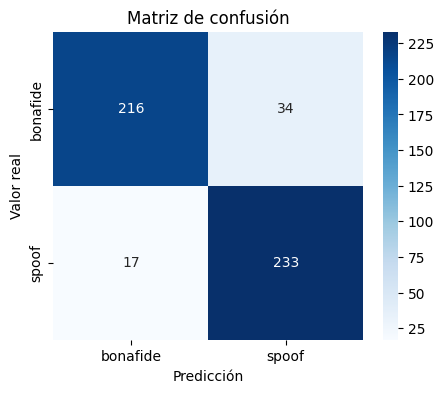

In [ ]:
# Matriz de confusión para ver en qué tipo de errores falla el modelo.

cm = confusion_matrix(y_dev, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["bonafide", "spoof"],
    yticklabels=["bonafide", "spoof"]
)
plt.xlabel("Predicción")
plt.ylabel("Valor real")
plt.title("Matriz de confusión")
plt.show()

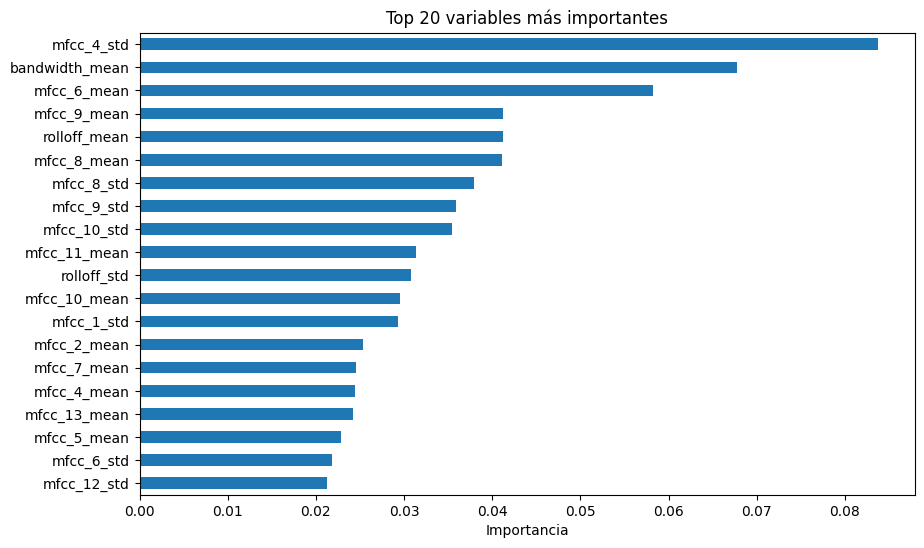

,0
mfcc_4_std,0.083729
bandwidth_mean,0.067736
mfcc_6_mean,0.058232
mfcc_9_mean,0.041223
rolloff_mean,0.041191
mfcc_8_mean,0.041089
mfcc_8_std,0.037933
mfcc_9_std,0.035942
mfcc_10_std,0.035391
mfcc_11_mean,0.031379


In [ ]:
# Mostramos las variables más importantes según el Random Forest.
# Esto ayuda a interpretar qué características acústicas han sido más útiles.

importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.head(20).sort_values().plot(kind="barh")
plt.title("Top 20 variables más importantes")
plt.xlabel("Importancia")
plt.show()

display(importances.head(20))

## Conclusión del baseline

En esta primera aproximación se ha construido un pipeline completo para la detección de voz falsa:
- se ha localizado y extraído el dataset de audio
- se han utilizado los protocolos oficiales para etiquetar cada muestra
- se han transformado los audios en variables numéricas mediante extracción de características acústicas
- se ha entrenado un modelo baseline con Random Forest
- se ha evaluado su rendimiento sobre el conjunto de desarrollo

Los resultados obtenidos son prometedores, ya que el modelo alcanza una accuracy cercana al 90% y muestra una buena capacidad para identificar audios spoof. Esto confirma que las propiedades acústicas del audio contienen información discriminativa relevante para el problema.

Como siguientes pasos, sería interesante:
- ampliar el número de muestras utilizadas
- comparar distintos modelos
- analizar los errores con mayor detalle
- explorar enfoques basados en espectrogramas o deep learning